# A Monetarist Theory of Price Levels

## Overview


We'll use linear algebra first to explain and then do some experiments with a "monetarist theory of price levels".

Economists call it a "monetary" or "monetarist" theory of price levels because effects on price levels occur via a central bank's decisions to print money supply. 

  * a goverment's fiscal policies determine whether its _expenditures_ exceed its _tax collections_
  * if its expenditures exceed its tax collections, the government can instruct the central bank to cover the difference by _printing money_
  * that leads to effects on the price level as price level path adjusts to equate the supply of money to the demand for money

Such a theory of price levels was described by Thomas Sargent and Neil Wallace in chapter 5 of 
{cite}`sargent2013rational`, which reprints a 1981 Federal Reserve Bank of Minneapolis article entitled "Unpleasant Monetarist Arithmetic". 

Sometimes this theory is also called a "fiscal theory of price levels" to emphasize the importance of fiscal deficits in shaping changes in the money supply. 

The theory has been extended, criticized, and applied by John Cochrane {cite}`cochrane2023fiscal`.

In another lecture {doc}`price level histories <inflation_history>`, we described some European hyperinflations that occurred in the wake of World War I.

Elemental forces at work in the fiscal theory of the price level help to understand those episodes.


According to this theory, when the government persistently spends more than it collects in taxes and prints money to finance the shortfall (the "shortfall" is called the "government deficit"), it puts upward pressure on the price level and generates
persistent inflation.

The "monetarist" or "fiscal theory of price levels" asserts that 

* to _start_ a persistent inflation the government begins persistently to run a money-financed government deficit

* to _stop_ a persistent inflation the government stops persistently running a money-financed government deficit

The model in this lecture is a "rational expectations" (or "perfect foresight") version of a model that Philip Cagan {cite}`Cagan` used to study the monetary dynamics of hyperinflations. 

While Cagan didn't use that "rational expectations" version of the model, Thomas Sargent {cite}`sargent1982ends` did when he studied the Ends of Four Big Inflations in Europe after World War I.

* this lecture {doc}`fiscal theory of the price level with adaptive expectations <cagan_adaptive>` describes a version of the model that does not impose "rational expectations" but instead uses 
  what Cagan and his teacher Milton Friedman called "adaptive expectations"

   * a reader of both lectures will notice that the algebra is less complicated in the present rational expectations version of the model
   * the difference in algebra complications can be traced to the following source: the adaptive expectations version of the model has more endogenous variables and more free parameters 

Some of our quantitative experiments with the rational expectations version of the model are designed to illustrate how the fiscal theory explains the abrupt end of those big inflations.

In those experiments, we'll encounter an instance of a "velocity dividend" that has sometimes accompanied successful inflation stabilization programs. 

To facilitate using linear matrix algebra as our main mathematical tool, we'll use a finite horizon version of the model.

As in the {doc}`present values <pv>` and {doc}`consumption smoothing<cons_smooth>` lectures, our mathematical tools are matrix multiplication and matrix inversion.


## Structure of the model


The model consists of

* a function that expresses the demand for real balances of government printed money as an inverse function of the public's expected rate of inflation

* an exogenous sequence of rates of growth of the money supply. The money supply grows because the government prints it to pay for goods and services

* an equilibrium condition that equates the demand for money to the supply

* a "perfect foresight" assumption that the public's expected rate of inflation equals the actual rate of inflation.
 
To represent the model formally, let 

* $ m_t $ be the log of the supply of nominal money balances;
* $\mu_t = m_{t+1} - m_t $ be the net rate of growth of nominal balances;
* $p_t $ be the log of the price level;
* $\pi_t = p_{t+1} - p_t $ be the net rate of inflation between $t$ and $ t+1$;
* $\pi_t^*$ be the public's expected rate of inflation between $t$ and $t+1$;
* $T$ the horizon -- i.e., the last period for which the model will determine $p_t$
* $\pi_{T+1}^*$ the terminal rate of inflation between times $T$ and $T+1$.

The demand for real balances $\exp\left(m_t^d - p_t\right)$ is governed by the following version of the Cagan demand function
 
$$ 
m_t^d - p_t = -\alpha \pi_t^* \: , \: \alpha > 0 ; \quad t = 0, 1, \ldots, T .
$$ (eq:caganmd)

This equation asserts that the demand for real balances
is inversely related to the public's expected rate of inflation with sensitivity $\alpha$.

People somehow acquire **perfect foresight** by their having solved a forecasting
problem.

This lets us set

$$ 
\pi_t^* = \pi_t , % \forall t 
$$ (eq:ree)

while equating demand for money to supply lets us set $m_t^d = m_t$ for all $t \geq 0$. 

The preceding equations then imply

$$
m_t - p_t = -\alpha(p_{t+1} - p_t)
$$ (eq:cagan)

To fill in details about what it means for private agents
to have perfect foresight, we subtract equation {eq}`eq:cagan` at time $ t $ from the same equation at $ t+1$ to get

$$
\mu_t - \pi_t = -\alpha \pi_{t+1} + \alpha \pi_t ,
$$

which we rewrite as a forward-looking first-order linear difference
equation in $\pi_s$ with $\mu_s$ as a "forcing variable":

$$
\pi_t = \frac{\alpha}{1+\alpha} \pi_{t+1} + \frac{1}{1+\alpha} \mu_t , \quad t= 0, 1, \ldots , T 
$$

where $ 0< \frac{\alpha}{1+\alpha} <1 $.

Setting $\delta =\frac{\alpha}{1+\alpha}$, let's us represent the preceding equation as

$$
\pi_t = \delta \pi_{t+1} + (1-\delta) \mu_t , \quad t =0, 1, \ldots, T
$$

Write this system of $T+1$ equations as the single matrix equation

$$
\begin{bmatrix} 1 & -\delta & 0 & 0 & \cdots & 0 & 0 \cr
                0 & 1 & -\delta & 0 & \cdots & 0 & 0 \cr
                0 & 0 & 1 & -\delta & \cdots & 0 & 0 \cr
                \vdots & \vdots & \vdots & \vdots & \vdots & -\delta & 0 \cr
                0 & 0 & 0 & 0 & \cdots & 1 & -\delta \cr
                0 & 0 & 0 & 0 & \cdots & 0 & 1 \end{bmatrix}
\begin{bmatrix} \pi_0 \cr \pi_1 \cr \pi_2 \cr \vdots \cr \pi_{T-1} \cr \pi_T 
\end{bmatrix} 
= (1 - \delta) \begin{bmatrix} 
\mu_0 \cr \mu_1 \cr \mu_2 \cr \vdots \cr \mu_{T-1} \cr \mu_T
\end{bmatrix}
+ \begin{bmatrix} 
0 \cr 0 \cr 0 \cr \vdots \cr 0 \cr \delta \pi_{T+1}^*
\end{bmatrix}
$$ (eq:pieq)

By multiplying both sides of equation {eq}`eq:pieq` by the inverse of the matrix on the left side, we can calculate

$$
\pi \equiv \begin{bmatrix} \pi_0 \cr \pi_1 \cr \pi_2 \cr \vdots \cr \pi_{T-1} \cr \pi_T 
\end{bmatrix} 
$$

It turns out that

$$
\pi_t = (1-\delta) \sum_{s=t}^T \delta^{s-t} \mu_s + \delta^{T+1-t} \pi_{T+1}^*
$$ (eq:fisctheory1)

We can represent the equations 

$$ 
m_{t+1} = m_t + \mu_t , \quad t = 0, 1, \ldots, T
$$

as the matrix equation

$$
\begin{bmatrix}
1 & 0 & 0 & \cdots & 0 & 0 \cr
-1 & 1 & 0 & \cdots & 0 & 0 \cr
0 & -1 & 1 & \cdots & 0 & 0 \cr
\vdots & \vdots & \vdots & \vdots & 0 & 0 \cr
0 & 0 & 0 & \cdots & 1 & 0 \cr
0 & 0 & 0 & \cdots & -1 & 1 
\end{bmatrix}
\begin{bmatrix} 
m_1 \cr m_2 \cr m_3 \cr \vdots \cr m_T \cr m_{T+1}
\end{bmatrix}
= \begin{bmatrix} 
\mu_0 \cr \mu_1 \cr \mu_2 \cr \vdots \cr \mu_{T-1} \cr \mu_T
\end{bmatrix}
+ \begin{bmatrix} 
m_0 \cr 0 \cr 0 \cr \vdots \cr 0 \cr 0
\end{bmatrix}
$$ (eq:eq101)

Multiplying both sides of equation {eq}`eq:eq101` with the inverse of the matrix on the left will give 

$$
m_t = m_0 + \sum_{s=0}^{t-1} \mu_s, \quad t =1, \ldots, T+1
$$ (eq:mcum)

Equation {eq}`eq:mcum` shows that the log of the money supply at $t$ equals the log of the initial money supply $m_0$
plus accumulation of rates of money growth between times $0$ and $T$.

## Continuation values

To determine the continuation inflation rate $\pi_{T+1}^*$ we shall proceed by applying the following infinite-horizon
version of equation {eq}`eq:fisctheory1` at time $t = T+1$:

$$
\pi_t = (1-\delta) \sum_{s=t}^\infty \delta^{s-t} \mu_s , 
$$ (eq:fisctheory2)

and by also assuming the following continuation path for $\mu_t$ beyond $T$:

$$
\mu_{t+1} = \gamma^* \mu_t, \quad t \geq T .
$$

Plugging the preceding equation into equation {eq}`eq:fisctheory2` at $t = T+1$ and rearranging we can deduce that

$$ 
\pi_{T+1}^* = \frac{1 - \delta}{1 - \delta \gamma^*} \gamma^* \mu_T
$$ (eq:piterm)

where we require that $\vert \gamma^* \delta \vert < 1$.

Let's implement and solve this model.


As usual, we'll start by importing some Python modules.

In [1]:
import numpy as np
from collections import namedtuple
import matplotlib.pyplot as plt

First, we store parameters in a `namedtuple`:

In [2]:
# Create the rational expectation version of Cagan model in finite time
CaganREE = namedtuple("CaganREE", 
                        ["m0",    # initial money supply
                         "μ_seq", # sequence of rate of growth
                         "α",     # sensitivity parameter
                         "δ",     # α/(1 + α)
                         "π_end"  # terminal expected inflation
                        ])

def create_cagan_model(m0=1, α=5, μ_seq=None):
    δ = α/(1 + α)
    π_end = μ_seq[-1]    # compute terminal expected inflation
    return CaganREE(m0, μ_seq, α, δ, π_end)

Now we can solve the model to compute $\pi_t$, $m_t$ and $p_t$ for $t =1, \ldots, T+1$ using the matrix equation above

In [3]:
def solve(model, T):
    m0, π_end, μ_seq, α, δ = (model.m0, model.π_end, 
                              model.μ_seq, model.α, model.δ)
    
    # Create matrix representation above
    A1 = np.eye(T+1, T+1) - δ * np.eye(T+1, T+1, k=1)
    A2 = np.eye(T+1, T+1) - np.eye(T+1, T+1, k=-1)

    b1 = (1-δ) * μ_seq + np.concatenate([np.zeros(T), [δ * π_end]])
    b2 = μ_seq + np.concatenate([[m0], np.zeros(T)])

    π_seq = np.linalg.solve(A1, b1)
    m_seq = np.linalg.solve(A2, b2)

    π_seq = np.append(π_seq, π_end)
    m_seq = np.append(m0, m_seq)

    p_seq = m_seq + α * π_seq

    return π_seq, m_seq, p_seq

### Some quantitative experiments

In the experiments below, we'll use formula {eq}`eq:piterm` as our terminal condition for expected inflation.

In devising these experiments, we'll make assumptions about $\{\mu_t\}$ that are consistent with formula
{eq}`eq:piterm`.

We  describe several such experiments.

In all of them, 

$$ 
\mu_t = \mu^* , \quad t \geq T_1
$$

so that, in terms of our notation and formula for $\pi_{T+1}^*$ above, $\gamma^* = 1$. 

#### Experiment 1: Foreseen sudden stabilization

In this experiment, we'll study how, when $\alpha >0$, a foreseen inflation stabilization has effects on inflation that proceed it.

We'll study a situation in which the rate of growth of the money supply is $\mu_0$
from $t=0$ to $t= T_1$ and then permanently falls to $\mu^*$ at $t=T_1$.

Thus, let $T_1 \in (0, T)$. 

So where $\mu_0 > \mu^*$, we assume that

$$
\mu_{t+1} = \begin{cases}
    \mu_0  , & t = 0, \ldots, T_1 -1 \\
     \mu^* , & t \geq T_1
     \end{cases}
$$

We'll start by executing a version of our "experiment 1" in which the government implements a _foreseen_ sudden permanent reduction in the rate of money creation at time $T_1$. 

Let's experiment with the following parameters

In [4]:
T1 = 60
μ0 = 0.5
μ_star = 0
T = 80

μ_seq_1 = np.append(μ0*np.ones(T1+1), μ_star*np.ones(T-T1))

cm = create_cagan_model(μ_seq=μ_seq_1)

# solve the model
π_seq_1, m_seq_1, p_seq_1 = solve(cm, T)

Now we use the following function to plot the result

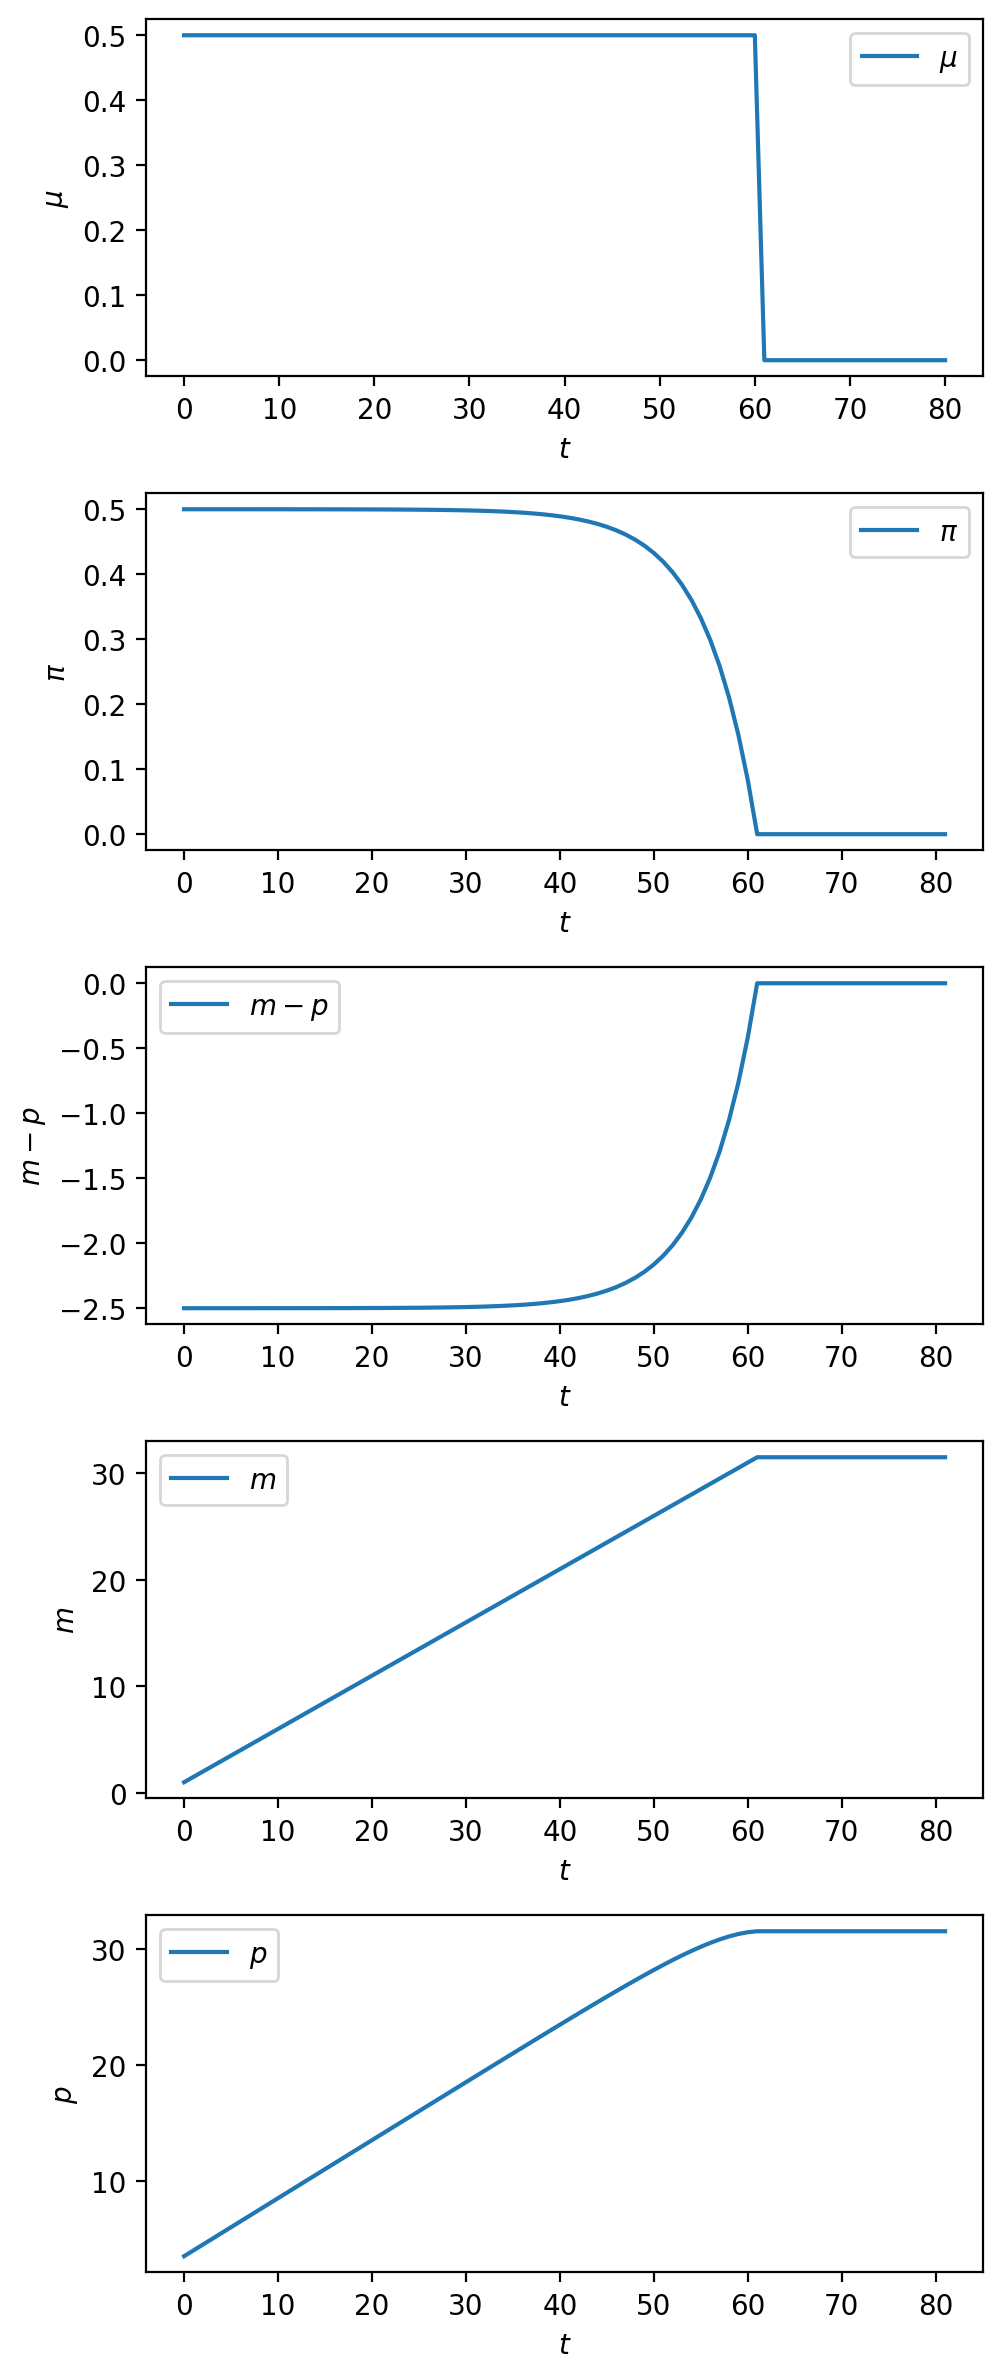

In [5]:
def plot_sequences(sequences, labels):
    fig, axs = plt.subplots(len(sequences), 1, figsize=(5, 12), dpi=200)
    for ax, seq, label in zip(axs, sequences, labels):
        ax.plot(range(len(seq)), seq, label=label)
        ax.set_ylabel(label)
        ax.set_xlabel('$t$')
        ax.legend()
    plt.tight_layout()
    plt.show()

sequences = (μ_seq_1, π_seq_1, m_seq_1 - p_seq_1, m_seq_1, p_seq_1)
plot_sequences(sequences, (r'$\mu$', r'$\pi$', r'$m - p$', r'$m$', r'$p$'))

The plot of the money growth rate $\mu_t$ in the top level panel portrays
a sudden reduction from $.5$ to $0$ at time $T_1 = 60$. 

This brings about a gradual reduction of the inflation rate $\pi_t$ that precedes the
money supply growth rate reduction at time $T_1$.

Notice how the inflation rate declines smoothly (i.e., continuously) to $0$ at $T_1$ -- 
unlike the money growth rate, it does not suddenly "jump" downward at $T_1$.

This is because the reduction in $\mu$ at $T_1$ has been foreseen from the start. 

While the log money supply portrayed in the bottom panel has a kink at $T_1$, the log price level does not -- it is "smooth" -- once again a consequence of the fact that the
reduction in $\mu$ has been foreseen.

To set the stage for our next experiment, we want to study the determinants of the price level a little more.


### The log price level

We can use equations {eq}`eq:caganmd` and {eq}`eq:ree`
to discover that the log of the price level satisfies

$$
p_t = m_t + \alpha \pi_t
$$ (eq:pformula2)

or, by using equation {eq}`eq:fisctheory1`,

$$ 
p_t = m_t + \alpha \left[ (1-\delta) \sum_{s=t}^T \delta^{s-t} \mu_s + \delta^{T+1-t} \pi_{T+1}^* \right] 
$$ (eq:pfiscaltheory2)

In our next experiment, we'll study a "surprise" permanent change in the money growth that beforehand 
was completely unanticipated. 

At time $T_1$ when the "surprise" money growth rate change occurs, to satisfy
equation {eq}`eq:pformula2`, the log of real balances jumps 
_upward_ as $\pi_t$ jumps _downward_.

But in order for $m_t - p_t$ to jump, which variable jumps, $m_{T_1}$ or $p_{T_1}$?

We'll study that interesting question next.

### What jumps?

What jumps at $T_1$?

Is it $p_{T_1}$ or $m_{T_1}$?

If we insist that the money supply $m_{T_1}$ is locked at its value $m_{T_1}^1$ inherited from the past, then formula {eq}`eq:pformula2` implies that the price level jumps downward at time $T_1$, to coincide with the downward jump in 
$\pi_{T_1}$ 

An alternative assumption about the money supply level is that as part of the "inflation stabilization",
the government resets $m_{T_1}$ according to

$$
m_{T_1}^2 - m_{T_1}^1 = \alpha (\pi_{T_1}^1 - \pi_{T_1}^2),
$$ (eq:eqnmoneyjump)

which describes how the government could reset the money supply at $T_1$ in response to the jump in expected inflation associated with monetary stabilization. 

Doing this would let the price level be continuous at $T_1$.

By letting money jump according to equation {eq}`eq:eqnmoneyjump` the monetary authority prevents the price level from _falling_ at the moment that the unanticipated stabilization arrives.

In various research papers about stabilizations of high inflations, the jump in the money supply described by equation {eq}`eq:eqnmoneyjump` has been called
"the velocity dividend" that a government reaps from implementing a regime change that sustains a permanently lower inflation rate.

#### Technical details about whether $p$ or $m$ jumps at $T_1$

We have noted that with a constant expected forward sequence $\mu_s = \bar \mu$ for $s\geq t$, $\pi_{t} =\bar{\mu}$.

A consequence is that at $T_1$, either $m$ or $p$ must "jump" at $T_1$.

We'll study both cases. 

#### $m_{T_{1}}$ does not jump.

$$
\begin{aligned}
m_{T_{1}}&=m_{T_{1}-1}+\mu_{0}\\\pi_{T_{1}}&=\mu^{*}\\p_{T_{1}}&=m_{T_{1}}+\alpha\pi_{T_{1}}
\end{aligned}
$$

Simply glue the sequences $t\leq T_1$ and $t > T_1$.

#### $m_{T_{1}}$ jumps.

We reset $m_{T_{1}}$ so that $p_{T_{1}}=\left(m_{T_{1}-1}+\mu_{0}\right)+\alpha\mu_{0}$, with $\pi_{T_{1}}=\mu^{*}$.

Then, 

$$ 
m_{T_{1}}=p_{T_{1}}-\alpha\pi_{T_{1}}=\left(m_{T_{1}-1}+\mu_{0}\right)+\alpha\left(\mu_{0}-\mu^{*}\right) 
$$

We then compute for the remaining $T-T_{1}$ periods with $\mu_{s}=\mu^{*},\forall s\geq T_{1}$ and the initial condition $m_{T_{1}}$ from above.

We are now technically equipped to discuss our next experiment.

#### Experiment 2: an unforeseen sudden stabilization

This experiment deviates a little bit from a pure version of our "perfect foresight"
assumption by assuming that a sudden permanent reduction in $\mu_t$ like that
analyzed in experiment 1 is completely unanticipated. 

Such a completely unanticipated shock is popularly known as an "MIT shock".

The mental experiment involves switching at time $T_1$ from an initial "continuation path" for $\{\mu_t, \pi_t\} $ to another path that involves a permanently lower inflation rate.  

**Initial Path:** $\mu_t = \mu_0$ for all $t \geq 0$. So this path is for $\{\mu_t\}_{t=0}^\infty$; the associated 
path for $\pi_t$ has $\pi_t = \mu_0$. 

**Revised Continuation Path** Where $ \mu_0 > \mu^*$, we construct a continuation path $\{\mu_s\}_{s=T_1}^\infty$
by setting $\mu_s = \mu^*$ for all $s \geq T_1$. The perfect foresight continuation path for 
$\pi$ is $\pi_s = \mu^*$ 

To capture a "completely unanticipated permanent shock to the $\{\mu_t\}$ process at time $T_1$, we simply glue the $\mu_t, \pi_t$
that emerges under path 2 for $t \geq T_1$ to the $\mu_t, \pi_t$ path that had emerged under path 1 for $ t=0, \ldots,
T_1 -1$.

We can do the MIT shock calculations mostly by hand. 

Thus, for path 1, $\pi_t = \mu_0 $ for all $t \in [0, T_1-1]$, while for path 2,
$\mu_s = \mu^*$ for all $s \geq T_1$. 

We now move on to experiment 2, our "MIT shock", completely unforeseen 
sudden stabilization.

We set this up so that the $\{\mu_t\}$ sequences that describe the sudden stabilization
are identical to those for experiment 1, the foreseen sudden stabilization.

The following code does the calculations and plots outcomes.

In [6]:
# path 1
μ_seq_2_path1 = μ0 * np.ones(T+1)

cm1 = create_cagan_model(μ_seq=μ_seq_2_path1)
π_seq_2_path1, m_seq_2_path1, p_seq_2_path1 = solve(cm1, T)

# continuation path
μ_seq_2_cont = μ_star * np.ones(T-T1)

cm2 = create_cagan_model(m0=m_seq_2_path1[T1+1], 
                         μ_seq=μ_seq_2_cont)
π_seq_2_cont, m_seq_2_cont1, p_seq_2_cont1 = solve(cm2, T-1-T1)


# regime 1 - simply glue π_seq, μ_seq
μ_seq_2 = np.concatenate((μ_seq_2_path1[:T1+1],
                          μ_seq_2_cont))
π_seq_2 = np.concatenate((π_seq_2_path1[:T1+1], 
                          π_seq_2_cont))
m_seq_2_regime1 = np.concatenate((m_seq_2_path1[:T1+1], 
                                  m_seq_2_cont1))
p_seq_2_regime1 = np.concatenate((p_seq_2_path1[:T1+1], 
                                  p_seq_2_cont1))

# regime 2 - reset m_T1
m_T1 = (m_seq_2_path1[T1] + μ0) + cm2.α*(μ0 - μ_star)

cm3 = create_cagan_model(m0=m_T1, μ_seq=μ_seq_2_cont)
π_seq_2_cont2, m_seq_2_cont2, p_seq_2_cont2 = solve(cm3, T-1-T1)

m_seq_2_regime2 = np.concatenate((m_seq_2_path1[:T1+1], 
                                  m_seq_2_cont2))
p_seq_2_regime2 = np.concatenate((p_seq_2_path1[:T1+1],
                                  p_seq_2_cont2))

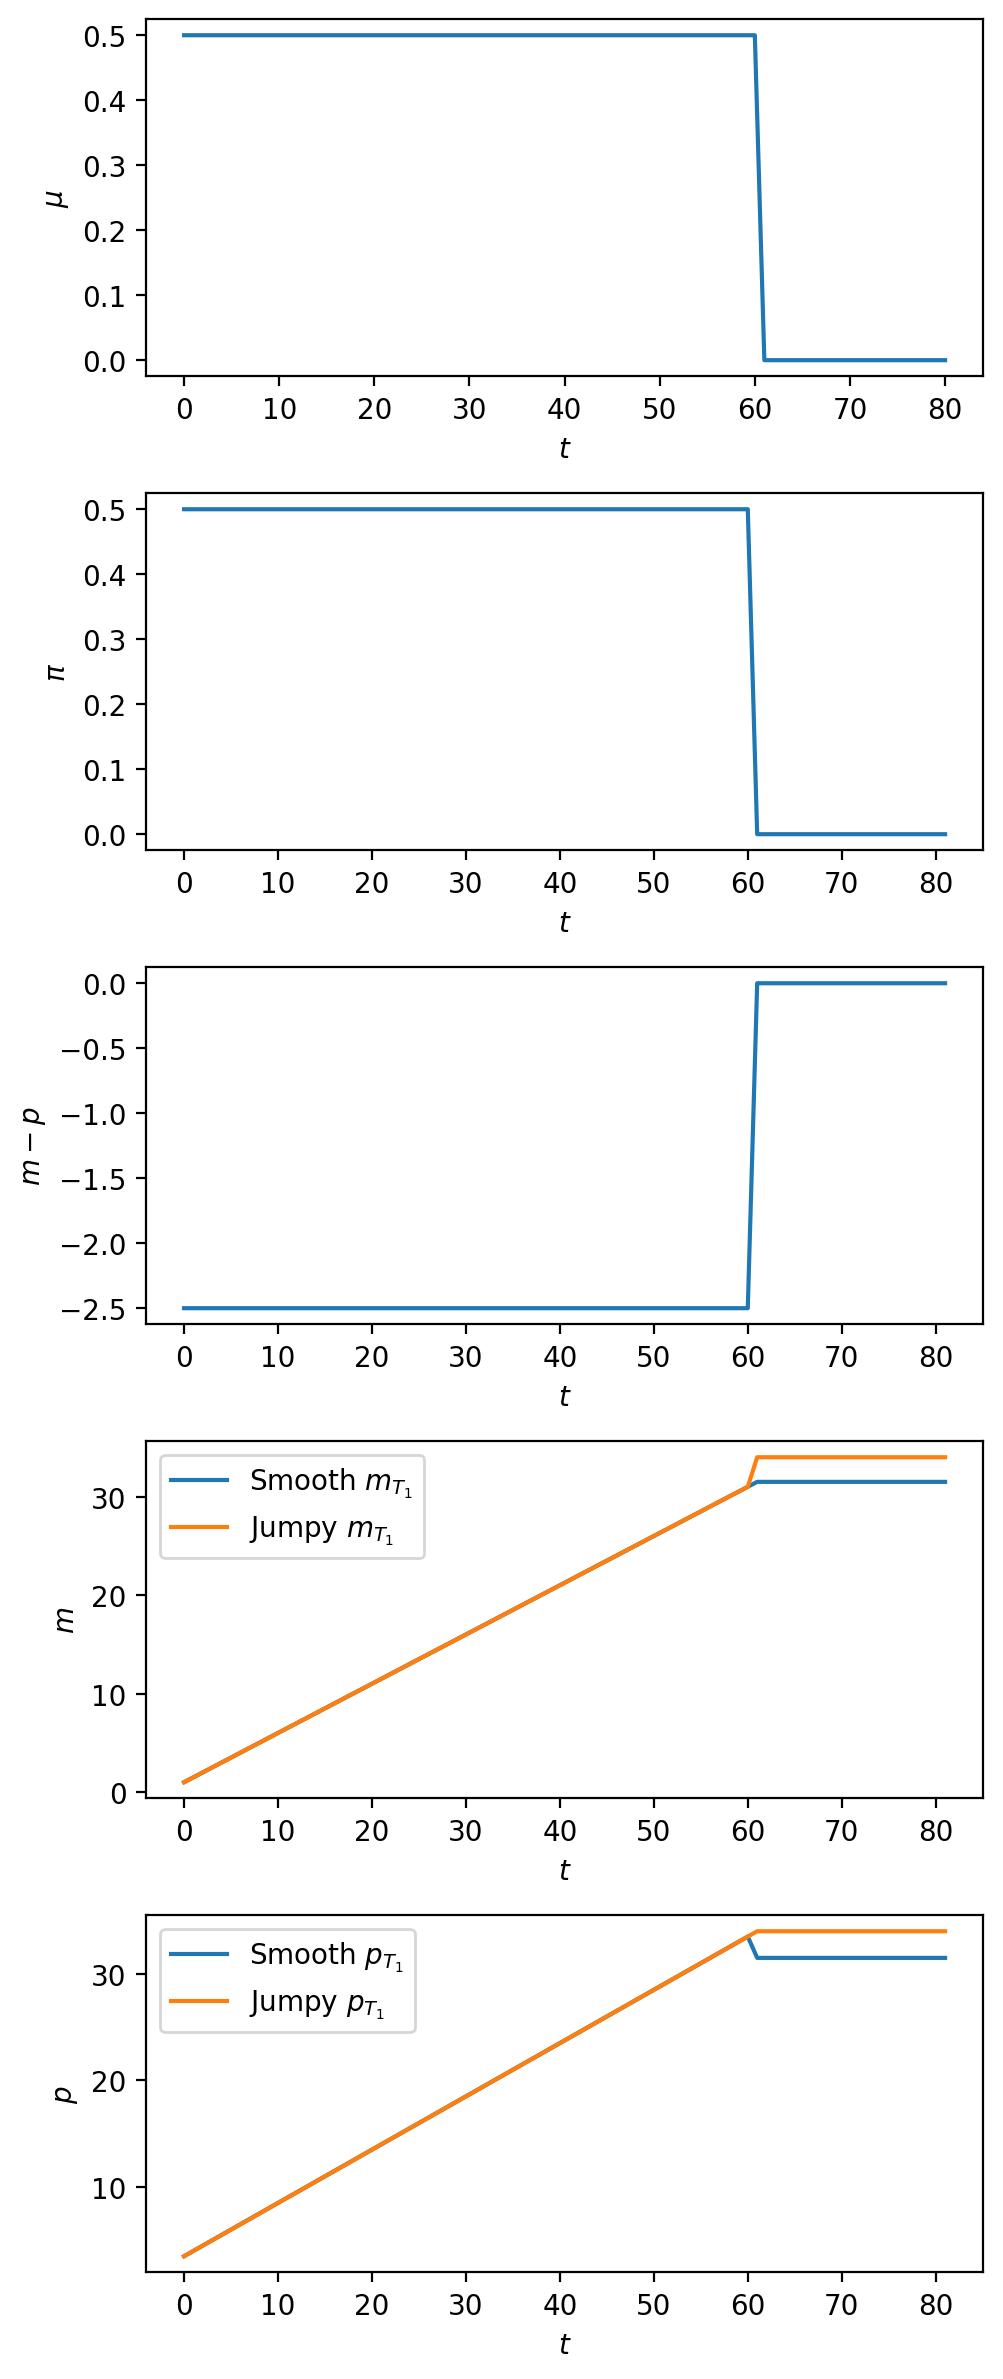

In [7]:
T_seq = range(T+2)

# plot both regimes
fig, ax = plt.subplots(5, 1, figsize=(5, 12), dpi=200)

# Configuration for each subplot
plot_configs = [
    {'data': [(T_seq[:-1], μ_seq_2)], 'ylabel': r'$\mu$'},
    {'data': [(T_seq, π_seq_2)], 'ylabel': r'$\pi$'},
    {'data': [(T_seq, m_seq_2_regime1 - p_seq_2_regime1)], 
     'ylabel': r'$m - p$'},
    {'data': [(T_seq, m_seq_2_regime1, 'Smooth $m_{T_1}$'), 
              (T_seq, m_seq_2_regime2, 'Jumpy $m_{T_1}$')], 
     'ylabel': r'$m$'},
    {'data': [(T_seq, p_seq_2_regime1, 'Smooth $p_{T_1}$'), 
              (T_seq, p_seq_2_regime2, 'Jumpy $p_{T_1}$')], 
     'ylabel': r'$p$'}
]

def experiment_plot(plot_configs, ax):
    # Loop through each subplot configuration
    for axi, config in zip(ax, plot_configs):
        for data in config['data']:
            if len(data) == 3:  # Plot with label for legend
                axi.plot(data[0], data[1], label=data[2])
                axi.legend()
            else:  # Plot without label
                axi.plot(data[0], data[1])
        axi.set_ylabel(config['ylabel'])
        axi.set_xlabel(r'$t$')
    plt.tight_layout()
    plt.show()
    
experiment_plot(plot_configs, ax)

We invite you to compare these graphs with corresponding ones for the foreseen stabilization analyzed in experiment 1 above.

Note how the inflation graph in the second panel is now identical to the 
money growth graph in the top panel, and how now the log of real balances portrayed in the third panel jumps upward at time $T_1$.

The bottom two panels plot $m$ and $p$ under two possible ways that $m_{T_1}$ might adjust
as required by the upward jump in $m - p$ at $T_1$.  

* the orange line lets $m_{T_1}$ jump upward in order to make sure that the log price level $p_{T_1}$ does not fall.

* the blue line lets $p_{T_1}$ fall while stopping the money supply from jumping.
  
Here is a way to interpret what the government is doing when the orange line policy is in place.

The government prints money to finance expenditure with the "velocity dividend" that it reaps from the increased demand for real balances brought about by the permanent decrease in the rate of growth of the money supply.

The next code generates a multi-panel graph that includes outcomes of both experiments 1 and 2.

That allows us to assess how important it is to understand whether the sudden permanent drop in $\mu_t$ at $t=T_1$ is fully unanticipated, as in experiment 1, or completely
unanticipated, as in experiment 2.

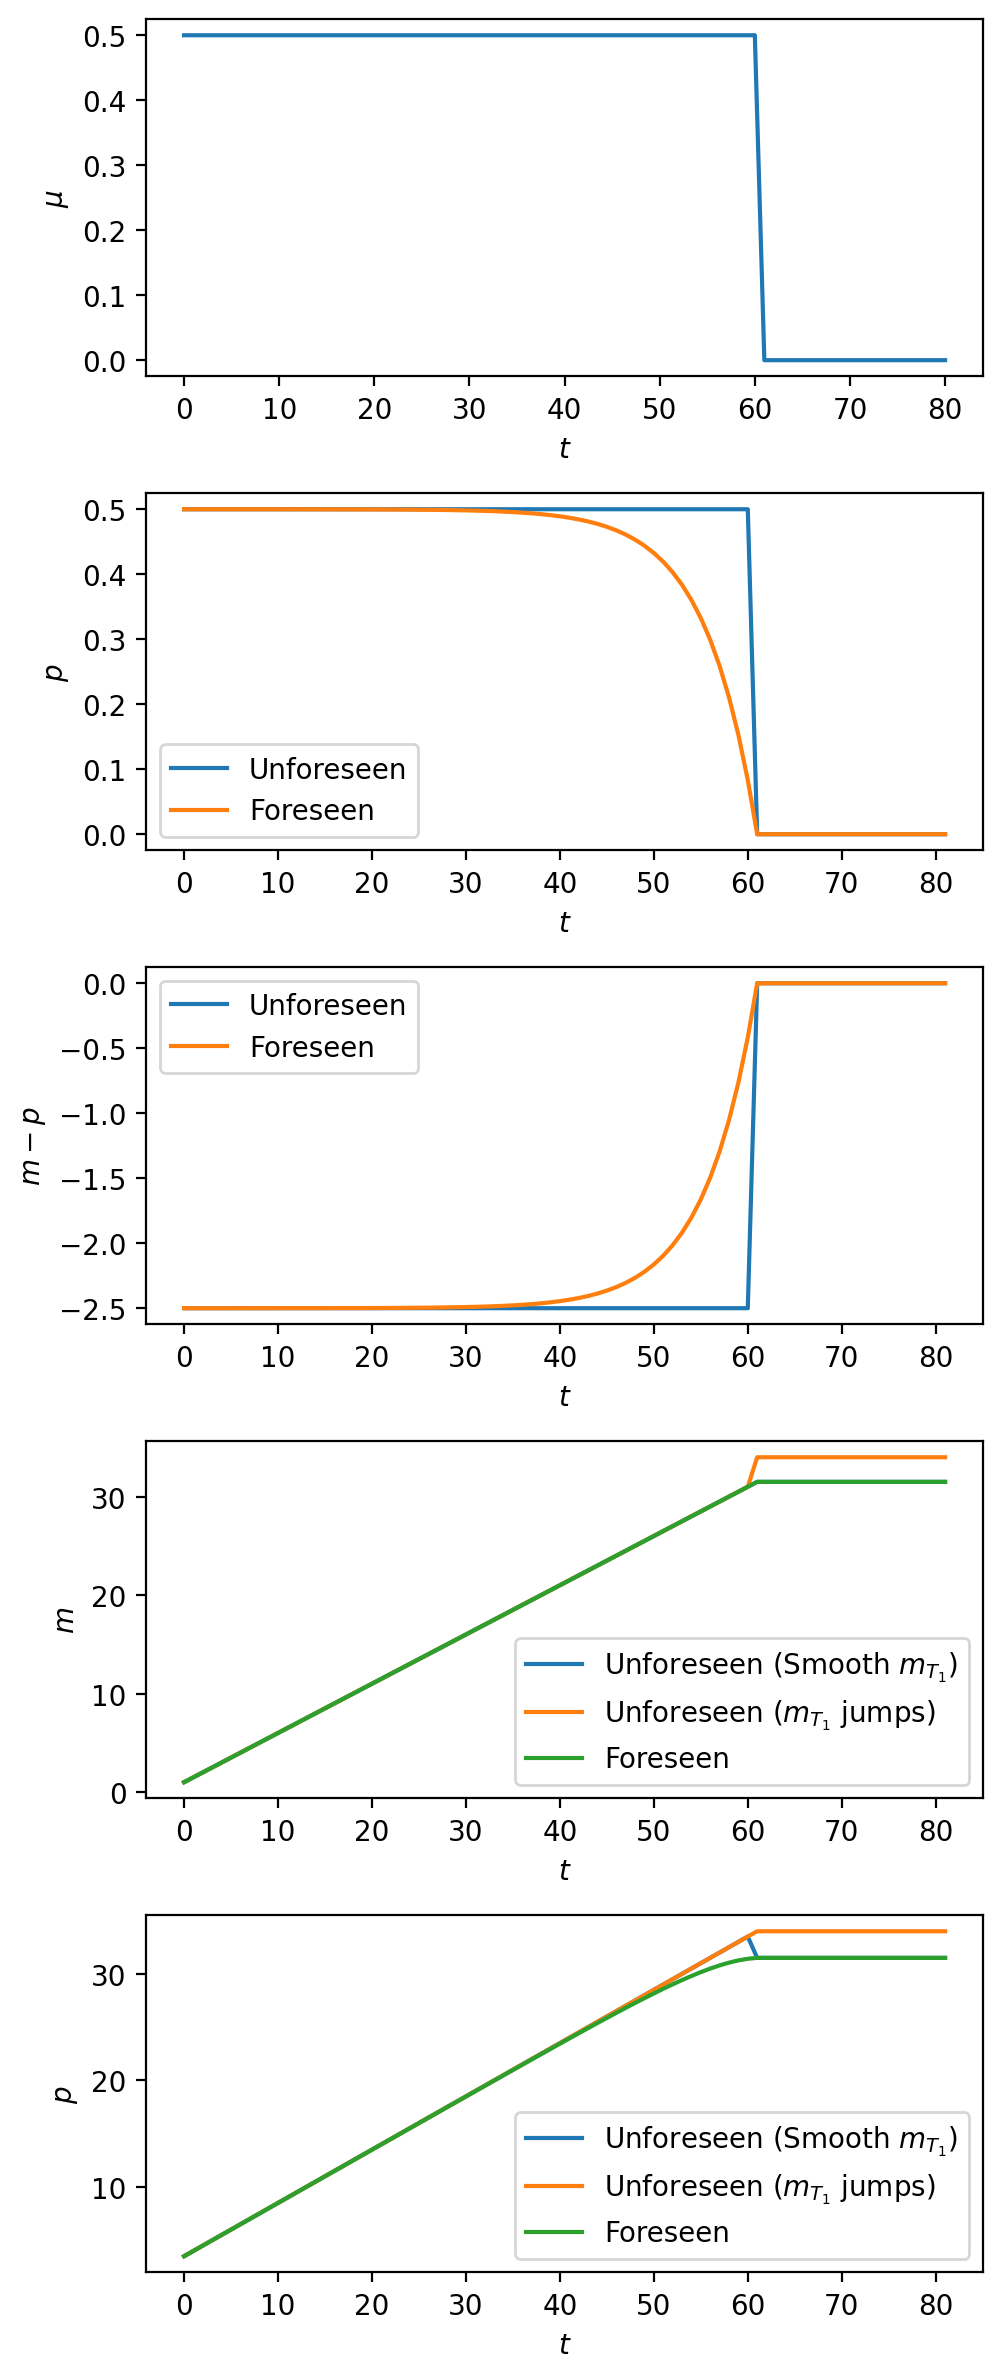

In [8]:
# compare foreseen vs unforeseen shock
fig, ax = plt.subplots(5, figsize=(5, 12), dpi=200)

plot_configs = [
    {'data': [(T_seq[:-1], μ_seq_2)], 'ylabel': r'$\mu$'},
    {'data': [(T_seq, π_seq_2, 'Unforeseen'), 
              (T_seq, π_seq_1, 'Foreseen')], 'ylabel': r'$p$'},
    {'data': [(T_seq, m_seq_2_regime1 - p_seq_2_regime1, 'Unforeseen'), 
              (T_seq, m_seq_1 - p_seq_1, 'Foreseen')], 'ylabel': r'$m - p$'},
    {'data': [(T_seq, m_seq_2_regime1, 'Unforeseen (Smooth $m_{T_1}$)'), 
              (T_seq, m_seq_2_regime2, 'Unforeseen ($m_{T_1}$ jumps)'),
              (T_seq, m_seq_1, 'Foreseen')], 'ylabel': r'$m$'},   
    {'data': [(T_seq, p_seq_2_regime1, 'Unforeseen (Smooth $m_{T_1}$)'), 
          (T_seq, p_seq_2_regime2, 'Unforeseen ($m_{T_1}$ jumps)'),
          (T_seq, p_seq_1, 'Foreseen')], 'ylabel': r'$p$'}   
]

experiment_plot(plot_configs, ax)

It is instructive to compare the preceding graphs with graphs of log price levels and inflation rates for data from four big inflations described in
{doc}`this lecture <inflation_history>`.

In particular, in the above graphs, notice how a gradual fall in inflation precedes the "sudden stop" when it has been anticipated long beforehand, but how
inflation instead falls abruptly when the permanent drop in money supply growth is unanticipated.

It seems to the author team at quantecon that the drops in inflation near the ends of the four hyperinflations described in {doc}`this lecture <inflation_history>`
more closely resemble outcomes from the experiment 2 "unforeseen stabilization". 

(It is fair to say that the preceding informal pattern recognition exercise should be supplemented with a more formal structural statistical analysis.)

#### Experiment 3

**Foreseen gradual stabilization**

Instead of a foreseen sudden stabilization of the type studied with experiment 1,
it is also interesting to study the consequences of a foreseen gradual stabilization.

Thus, suppose that $\phi \in (0,1)$, that $\mu_0 > \mu^*$, and that for $t = 0, \ldots, T-1$

$$
\mu_t = \phi^t \mu_0 + (1 - \phi^t) \mu^* .
$$ 

Next we perform an experiment in which there is a perfectly foreseen _gradual_ decrease in the rate of growth of the money supply.

The following code does the calculations and plots the results.

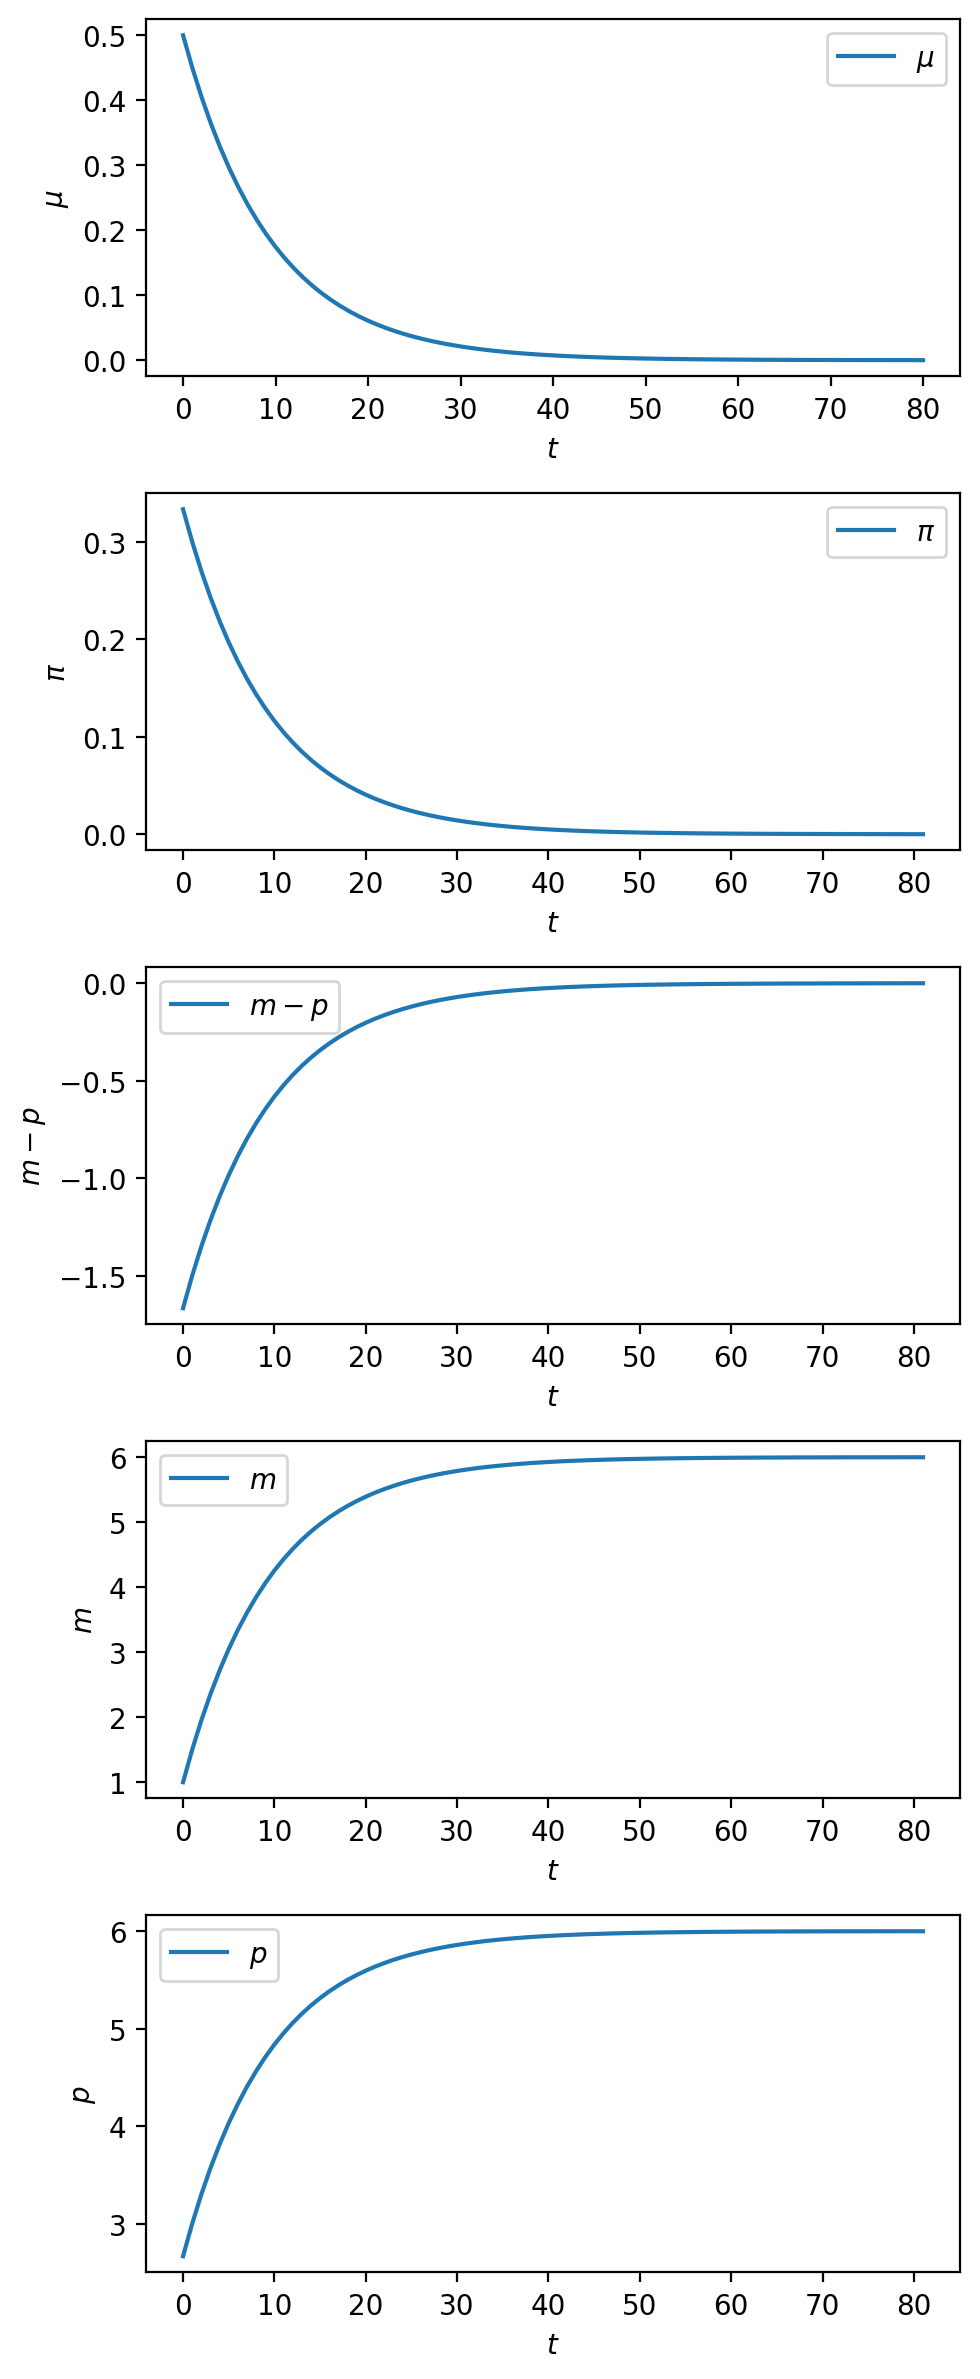

In [9]:
# parameters
ϕ = 0.9
μ_seq_stab = np.array([ϕ**t * μ0 + (1-ϕ**t)*μ_star for t in range(T)])
μ_seq_stab = np.append(μ_seq_stab, μ_star)

cm4 = create_cagan_model(μ_seq=μ_seq_stab)

π_seq_4, m_seq_4, p_seq_4 = solve(cm4, T)

sequences = (μ_seq_stab, π_seq_4, 
             m_seq_4 - p_seq_4, m_seq_4, p_seq_4)
plot_sequences(sequences, (r'$\mu$', r'$\pi$', 
                           r'$m - p$', r'$m$', r'$p$'))

## Sequel

Another lecture {doc}`monetarist theory of price levels with adaptive expectations <cagan_adaptive>` describes an "adaptive expectations" version of Cagan's model.

The dynamics become more complicated and so does the algebra.

Nowadays, the "rational expectations" version of the model is more popular among central bankers and economists advising them.